In [7]:
import pandas as pd
import numpy as np
import os

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import matplotlib.pyplot as plt

In [8]:
# Load the master view from ETL pipeline
df = pd.read_csv('aviation_data/Alice_Master_Analysis_View.csv')
print(df.columns.tolist())

['flight_id', 'timestamp_min', 'battery_soc_pct', 'altitude_ft', 'payload_lbs', 'ambient_temp_c', 'ticket_revenue', 'firmware_version', 'is_alert', 'phase']


In [9]:
# # 3.1: Feature Engineering (The Robust Way)

# 1. Calculate the "Delta" for each flight individually
df = df.sort_values(['flight_id', 'timestamp_min'])

# 2. Calculate Burn Rate explicitly to avoid rename() inside agg()
# Logic: (Start_SoC - End_SoC) / Duration
def calculate_flight_stats(group):
    # Duration in minutes
    duration = len(group) 
    soc_start = group['battery_soc_pct'].iloc[0]
    soc_end = group['battery_soc_pct'].iloc[-1]
    
    return pd.Series({
        'burn_rate_per_min': (soc_start - soc_end) / duration,
        'payload_lbs': group['payload_lbs'].iloc[0],
        'ambient_temp_c': group['ambient_temp_c'].iloc[0]
    })

flight_stats = df.groupby('flight_id').apply(calculate_flight_stats).reset_index()

print(f"Total flights processed: {len(flight_stats)}")
print(f"Columns: {flight_stats.columns.tolist()}")
display(flight_stats.head())

Total flights processed: 100
Columns: ['flight_id', 'burn_rate_per_min', 'payload_lbs', 'ambient_temp_c']


/var/folders/l8/p5_52krd0v30xh7p4bj1b7bm0000gn/T/ipykernel_76155/592865718.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flight_stats = df.groupby('flight_id').apply(calculate_flight_stats).reset_index()


,flight_id,burn_rate_per_min,payload_lbs,ambient_temp_c
0,FL-00001,1.336184,1249.080238,-3.428541
1,FL-00002,1.310453,2401.428613,26.820521
2,FL-00003,1.336630,1963.987884,10.717799
3,FL-00004,1.243378,1697.316968,20.428535
4,FL-00005,1.202538,812.037281,40.378324


In [14]:
# 3.2: Model Evolution (Linear vs. Polynomial)

# Define features x and target Y
X = flight_stats[['payload_lbs', 'ambient_temp_c']]
y = flight_stats['burn_rate_per_min']

# Split training and testing data: 8/2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3.2.1 Model A: Linear Regression (The "Control" Group)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print(f"(Linear) R-squared: {linear_model.score(X_test, y_test):.4f}")

(Linear) R-squared: 0.7146


In [ ]:
# 3.2.2 Model B: Polynomial Enhancement
# Battery discharge is non-linear; polynomial features capture the curve better.

polynomial_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
polynomial_model.fit(X_train, y_train)
print(f"(Polynomial) R-squared: {polynomial_model.score(X_test, y_test):.4f}")

(Polynomial) R-squared: 0.9611


In [19]:
# 3.2 Final Selection
r2_baseline = linear_model.score(X_test, y_test)
r2_enhanced = polynomial_model.score(X_test, y_test)

# Choose the model that better captures the non-linear physics of battery drain
if r2_enhanced > r2_baseline:
    print(f"Polynomial features improved R2 from {r2_baseline:.4f} to {r2_enhanced:.4f}")
    model = polynomial_model
    model_type = "Polynomial (Enhnaced)"
else:
    print("Proceeding with Linear Regression.")
    model = linear_model
    model_type = "Linear (Baseline)"

print(f"Final Model: {model_type}")

Polynomial features improved R2 from 0.7146 to 0.9611
Final Model: Polynomial (Enhnaced)


In [23]:
# 3.3 Stress Test 
# Test model reliability

# Test 2 different Scenarios
#   1. Standard payload and optimal temp at 25C
#   2. 2500lbs max. Payload & Critical Heat 

scenarios = pd.DataFrame([
    [1800, 25], 
    [2500, 45] 
], columns=['payload_lbs', 'ambient_temp_c'])

predicted_burn_rates = model.predict(scenarios)
planned_duration = 60

for i, rate in enumerate(predicted_burn_rates):
    end_soc = 100 - (rate * planned_duration)
    status = "CLEARED" if end_soc >= 20 else "REJECTED"
    
    print(f"Scenario {i+1} ({scenarios.iloc[i,0]} lbs @ {scenarios.iloc[i,1]}C)")
    print(f"Projected Landing SoC: {end_soc:.1f}%, Status: {status}\n")

Scenario 1 (1800 lbs @ 25C)
Projected Landing SoC: 24.6%, Status: CLEARED

Scenario 2 (2500 lbs @ 45C)
Projected Landing SoC: 12.8%, Status: REJECTED



In [36]:
# 3.4: OOP - Alice Fleet Manager Engine
# Goal: Encapsulate the ML logic into a reusable production-grade object.

class AliceFleetManager:
    def __init__(self, trained_model):
        self.model = trained_model
        self.safety_limit = 20.0 # FAA VFR Mandate

    def run_safety_audit(self, payload, temp, planned_min=60):
        input_df = pd.DataFrame([[payload, temp]], columns=['payload_lbs', 'ambient_temp_c'])
        
        # Inference using our 96.1% accuracy model
        burn_rate = self.model.predict(input_df)[0]
        final_soc = 100 - (burn_rate * planned_min)
        
        # Returning a structured dictionary for downstream integration
        return {
            "status": "CLEARED" if final_soc >= self.safety_limit else "REJECTED",
            "projected_landing_soc": round(final_soc, 2),
            "estimated_burn_rate": round(burn_rate, 4),
            "safety_margin": round(final_soc - self.safety_limit, 2)
        }

commander = AliceFleetManager(model)

In [37]:
# Test Case 1: Standard Load
r1 = commander.run_safety_audit(1800, 25, 60)
print(f"Sortie 1: {r1['status']} (Margin: {r1['safety_margin']}%)")
print(f"Projected Landing SoC: {r1['projected_landing_soc']}%")

Sortie 1: CLEARED (Margin: 4.59%)
Projected Landing SoC: 24.59%


In [38]:
# Scenario 2 (Longer flight)
r2 = commander.run_safety_audit(2500, 45, 80)
print(f"Sortie 2: {r2['status']} (Margin: {r2['safety_margin']}%)")
print(f"Projected Landing SoC: {r2['projected_landing_soc']}%")

Sortie 2: REJECTED (Margin: -36.27%)
Projected Landing SoC: -16.27%


In [39]:
# Scenario 3 (Optimized)
r3 = commander.run_safety_audit(2500, 45, 58)
print(f"Sortie 3: {r3['status']} (Margin: {r3['safety_margin']}%)")
print(f"Projected Landing SoC: {r3['projected_landing_soc']}%")

Sortie 3: REJECTED (Margin: -4.3%)
Projected Landing SoC: 15.7%


In [40]:
# 3.5 OOP - Batch Operational Audit 

test_payloads = [1000, 1500, 2000, 2500]
print("Payload Stress Test")

for p in test_payloads:
    res = commander.run_safety_audit(p, 25)
    
    print(f"Payload: {p:<5} lbs | Status: {res['status']:<5} | Margin: {res['safety_margin']:>5}%")

Payload Stress Test
Payload: 1000  lbs | Status: CLEARED | Margin: 10.74%
Payload: 1500  lbs | Status: CLEARED | Margin:  7.06%
Payload: 2000  lbs | Status: CLEARED | Margin:  2.84%
Payload: 2500  lbs | Status: REJECTED | Margin: -1.93%


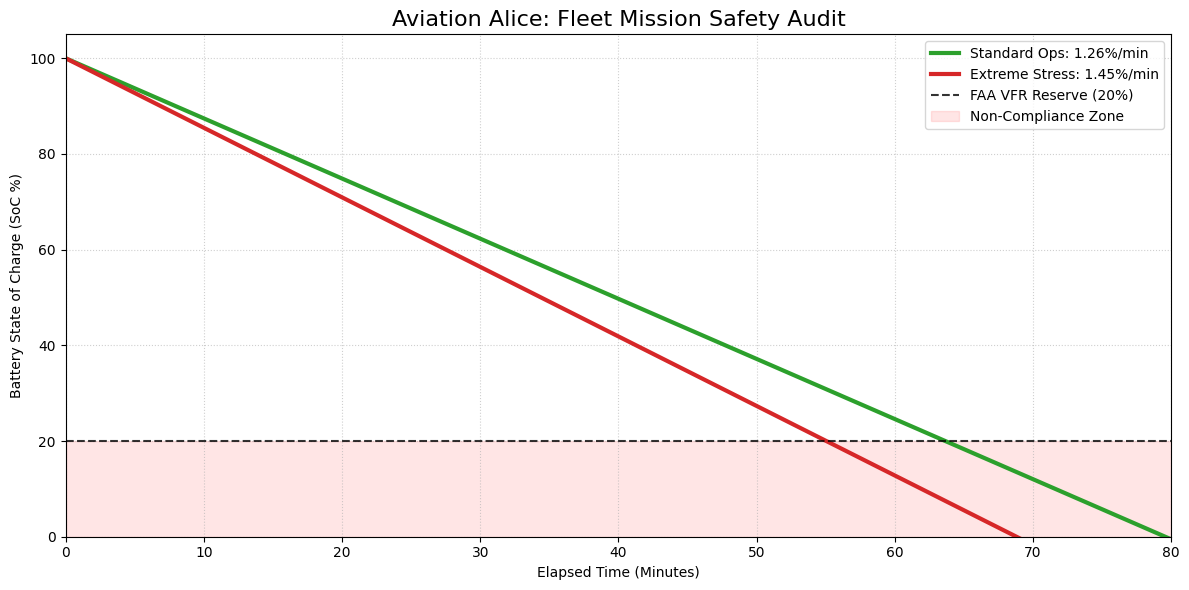

In [45]:
# # 3.6 Executive Visualization
# Goal: Visualize the impact of payload and temperature on the 20% FAA safety mandate.

time_axis = np.arange(0, 81) # 80-minute flight window

# 1. Generate SoC Curves for 2 scenarios
# Scenario A: Standard Regional Logistics (1800 lbs @ 25C)
std_report = commander.run_safety_audit(payload=1800, temp=25)
rate_std = std_report['estimated_burn_rate']

# Scenario B: Extreme Summer Load (2500 lbs @ 45C)
stress_report = commander.run_safety_audit(payload=2500, temp=45)
rate_ext = stress_report['estimated_burn_rate']

soc_standard = 100 - (rate_std * time_axis)
soc_extreme = 100 - (rate_ext * time_axis)

# 2. Plotting the Safety Narrative
plt.figure(figsize=(12, 6))

# Plot Fleet Performance Lines
plt.plot(time_axis, soc_standard, label=f'Standard Ops: {rate_std:.2f}%/min', color='#2ca02c', linewidth=3)
plt.plot(time_axis, soc_extreme, label=f'Extreme Stress: {rate_ext:.2f}%/min', color='#d62728', linewidth=3)

# Add FAA Mandate
plt.axhline(y=20, color='black', linestyle='--', alpha=0.8, label='FAA VFR Reserve (20%)')

# "Breach Zone" 
plt.fill_between(time_axis, 0, 20, color='red', alpha=0.1, label='Non-Compliance Zone')

# Formatting 
plt.title("Aviation Alice: Fleet Mission Safety Audit", fontsize=16)
plt.xlabel("Elapsed Time (Minutes)", fontsize=10)
plt.ylabel("Battery State of Charge (SoC %)", fontsize=10)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, 105)
plt.xlim(0, 80)

plt.tight_layout()
plt.show()

In [47]:
# Polynomial Coefficients for Excel - Mission ROI
poly = model.named_steps['polynomialfeatures']
reg = model.named_steps['linearregression']

print(f"Intercept: {reg.intercept_}")
print(f"Coefficients: {reg.coef_}")

Intercept: 1.1743226321474063
Coefficients: [ 0.00000000e+00  1.00087618e-04 -1.08917598e-02  1.81202752e-08
 -9.07277219e-07  2.50772768e-04]
